<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_WEEK13_2_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 13.3 적대적 생성 신경망

- 생성모델은 최대한 진짜와 비슷한 데이터를 생성하려는 생성자와 진짜와 가짜를 구분하려는 판별자가 각각 존재하여 저로 적대적으로 학습
- 적대적 학습
  - 판별자를 먼저 학습시킨 후 생성자 학습
  - 실제 이미지 입력 후 신경망이 해당 이미지를 진짜 분류하도록 학습
  - 생성자가 생성한 모조 이미지를 입력하여 해당 이미지를 가짜로 분류하도록 학습

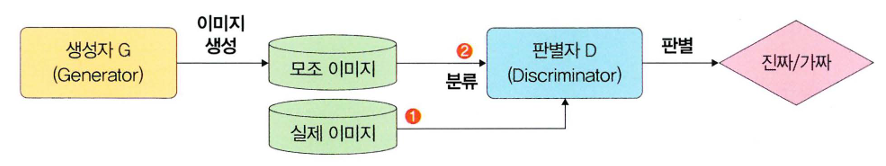

> 생성자는 분류에 성공할 확률을 낮추고 판별자는 분류에 성공할 확률을 높이며 서로 경쟁적으로 발전시키는 구조

## 13.3.1 GAN 동작 원리

- 적대적 신경망 = GAN

< 판별자 D >
- 주어진 이미지가 진짜 이미지인지, 가짜 이미지인지 구별
> 이미지 x가 주어졌을 때 판별자 D의 출력에 해당하는 D(x)가 진짜 이미지일 확률 반환

< 생성자 G >
- 판별자가 구별할 수 없을 만큼 진짜와 같은 모조 이미지를 노이즈 데이터를 사용해 만들어냄
> 실제 이미지인 z가 주어졌을 때, 판별자는 z 학습 -> 생성자는 임의의 노이즈 데이터를 사용하여 모조 이미지 z'(G(z)) 생성 -> 이 G(z)를 다시 판별자 D의 입력으로 주면 판별자는 G(z)가 실제 이미지일 확률 반환



< GAN 손실 함수 >
- GAN은 판별자 D와 생성자 G가 서로 반대 목표를 가지는 구조
  - 판별자 D 학습 시, 생성자 G는 고정
  - 실제 이미지는 높은 확률로 진짜라고 판단하도록 학습
  - 모조 이미지는 낮은 확률로 진짜라고 판단하도록 학습
< GAN의 전체 손실 함수 >
- 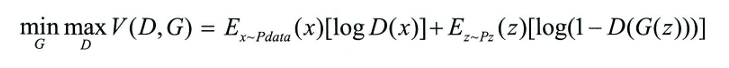

< 판별자 D의 학습 목표 >
- 판별자 D는 실제 이미지와 생성 이미지 구별 능력을 높이는 방향으로 학습
- max log(D(x))+log(1−D(G(z)))
- 판별자의 이상적인 판단
  - 실제 이미지 x 입력 → D(x)=1
  - 생성 이미지 G(z) 입력 → D(G(z))=0
  > 즉, 판별자는 다음 두 값을 모두 크게 만드는 것이 목표
    - log(D(x))
    - log(1−D(G(z)))
> 판별자 입장에서는 실제 이미지는 진짜로, 생성자가 만든 이미지는 가짜로 분류하는 것이 최적의 결과

< 생성자 G의 학습 목표 >
- 생성자 G는 판별자를 속일 수 있는 이미지를 만드는 방향으로 학습
- min log(1−D(G(z)))
- 생성자의 이상적인 결과
  - 생성 이미지 G(z)를 판별자가 진짜라고 판단
  - 즉, D(G(z))=1이 되는 것이 목표
- 생성자는 판별자가 생성 이미지를 가짜라고 판단할 확률을 낮추도록 학습
  - 판별자가 생성 이미지를 가짜로 잘 맞히면 생성자 성능이 낮은 것
  - 판별자가 생성 이미지를 진짜로 착각하면 생성자 성능이 좋은 것
> 생성자 입장에서는 판별자가 가짜 이미지를 진짜라고 판단하도록 만드는 것이 최적의 결과

< GAN 학습 방식 정리 >
- GAN은 판별자와 생성자의 파라미터를 번갈아 업데이트하며 학습
- 판별자 학습 시
  - 생성자의 파라미터는 고정
  - 판별자의 파라미터만 업데이트
- 생성자 학습 시
  - 판별자의 파라미터는 고정
  - 생성자의 파라미터만 업데이트
> 결과적으로 판별자는 진짜와 가짜를 더 잘 구별하도록 발전 & 생성자는 판별자가 구별하지 못할 정도로 진짜 같은 데이터를 생성하도록 발전

## 13.3.2 GAN 구현

In [1]:
# 13-22 라이브러리 호출

import imageio  # 이미지 데이터를 읽고 쓸 수 있는 라이브러리
from tqdm import tqdm  # 반복문 진행 상황 표시

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pylab as plt

from torchvision.utils import make_grid, save_image
import torchvision.datasets as datasets
import torchvision.transforms as transforms

plt.style.use('ggplot')  # 그래프 스타일 설정

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# 13-23 변수 값 설정

batch_size = 128
epochs = 50

sample_size = 64  # 생성자에 넣을 고정 노이즈 벡터 개수
nz = 128          # 잠재 벡터의 크기, 생성자 입력 크기
k = 1             # 판별자 업데이트 스텝 수

In [3]:
# 13-24 MNIST를 내려받은 후 정규화

transform = transforms.Compose([
    transforms.ToTensor(),                 # 이미지를 텐서로 변환
    transforms.Normalize((0.5,), (0.5,))    # 평균 0.5, 표준편차 0.5로 정규화
])

train_dataset = datasets.MNIST(
    root="../chap13/data",
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0   # Colab에서 RAM 터지면 0으로 두는 게 안전
)

In [4]:
# 13-25 생성자 네트워크 생성

class Generator(nn.Module):
    def __init__(self, nz):
        super(Generator, self).__init__()

        self.nz = nz

        self.main = nn.Sequential(
            nn.Linear(self.nz, 256),  # 128차원 노이즈 → 256차원 특징
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),  # 256차원 노이즈 → 512차원 특징
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),  # 512차원 노이즈 → 1024차원 특징
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 784),
            nn.Tanh()  # 출력값을 -1~1 범위로 조정
        )

    def forward(self, x):
        return self.main(x).view(-1, 1, 28, 28)  # 배치 크기 × 1 × 28 × 28 형태로 변환

랜덤 노이즈 z

→ 128차원 입력

→ 256

→ 512

→ 1024

→ 784

→ 1 × 28 × 28 이미지 생성

In [5]:
# 13-26 판별자 네트워크 생성

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.n_input = 784  # 28 × 28 이미지 크기

        # 입력 이미지가 이 층들을 차례대로 통과하면서 진짜/가짜 확률을 출력
        self.main = nn.Sequential(
            nn.Linear(self.n_input, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),  # 필요한 핵심 특징을 압축
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),  # 점점 더 최종 판단에 가까운 정보로 압축
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()  # 진짜일 확률을 0~1 사이 값으로 출력
        )

    def forward(self, x):
        x = x.view(-1, 784)  # 이미지를 1차원 벡터로 변환
        return self.main(x)  # 진짜/가짜 분류값 반환

이미지 입력

→ 784차원 벡터로 펼침

→ Linear(784, 1024)

→ Linear(1024, 512)

→ Linear(512, 256)

→ Linear(256, 1)

→ Sigmoid()

→ 진짜일 확률 출력

In [6]:
# 13-27 생성자와 판별자 네트워크 초기화

generator = Generator(nz).to(device)
discriminator = Discriminator().to(device)

print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [7]:
# 13-28 옵티마이저와 손실 함수 정의

optim_g = optim.Adam(generator.parameters(), lr=0.0002)
optim_d = optim.Adam(discriminator.parameters(), lr=0.0002)

criterion = nn.BCELoss()  # 이진 분류 손실 함수

losses_g = []  # 매 에포크마다 생성자 오차 저장
losses_d = []  # 매 에포크마다 판별자 오차 저장
images = []    # 생성자가 만든 이미지 저장

In [8]:
# 13-29 생성된 이미지 저장 함수 정의

def save_generator_image(image, path):
    save_image(image, path)

In [9]:
# 13-30 판별자 학습을 위한 함수

def train_discriminator(optimizer, data_real, data_fake):
    b_size = data_real.size(0)  # 배치 크기

    real_label = torch.ones(b_size, 1).to(device)   # 진짜 데이터 라벨 = 1
    fake_label = torch.zeros(b_size, 1).to(device)  # 가짜 데이터 라벨 = 0

    optimizer.zero_grad()

    output_real = discriminator(data_real)
    loss_real = criterion(output_real, real_label)  # 진짜 데이터에 대한 오차

    output_fake = discriminator(data_fake)
    loss_fake = criterion(output_fake, fake_label)  # 가짜 데이터에 대한 오차

    loss_real.backward()
    loss_fake.backward()

    optimizer.step()

    return loss_real + loss_fake  # 판별자의 총 오차 반환

In [10]:
# 13-31 생성자 학습을 위한 함수

def train_generator(optimizer, data_fake):
    b_size = data_fake.size(0)

    real_label = torch.ones(b_size, 1).to(device)  # 생성자는 가짜 이미지를 진짜로 판단받는 것이 목표

    optimizer.zero_grad()

    output = discriminator(data_fake)
    loss = criterion(output, real_label)

    loss.backward()
    optimizer.step()

    return loss

In [11]:
# 13-32 모델 학습

import os

os.makedirs("../chap13/img", exist_ok=True)

generator.train()      # 생성자를 학습 모드로 설정
discriminator.train()  # 판별자를 학습 모드로 설정

fixed_noise = torch.randn(sample_size, nz).to(device)  # 이미지 확인용 고정 노이즈

for epoch in range(epochs):
    loss_g = 0.0  # 생성자 오차 누적
    loss_d = 0.0  # 판별자 오차 누적

    for idx, data in tqdm(enumerate(train_loader), total=len(train_loader)):
        image, _ = data
        image = image.to(device)
        b_size = image.size(0)

        # 판별자 학습
        for step in range(k):
            noise = torch.randn(b_size, nz).to(device)
            data_fake = generator(noise).detach()  # 판별자 학습 시 생성자 그래프 차단
            data_real = image

            d_loss = train_discriminator(optim_d, data_real, data_fake)
            loss_d += d_loss.item()  # 숫자만 저장

        # 생성자 학습
        noise = torch.randn(b_size, nz).to(device)
        data_fake = generator(noise)

        g_loss = train_generator(optim_g, data_fake)
        loss_g += g_loss.item()  # 숫자만 저장

    # 에포크 단위 평균 loss 계산
    epoch_loss_g = loss_g / len(train_loader)
    epoch_loss_d = loss_d / len(train_loader)

    losses_g.append(epoch_loss_g)
    losses_d.append(epoch_loss_d)

    # 생성 이미지는 매 에포크마다 한 번만 저장
    with torch.no_grad():
        generated_img = generator(fixed_noise).cpu()
        generated_img = make_grid(generated_img)
        save_generator_image(
            generated_img,
            f"../chap13/img/gen_img{epoch}.png"
        )

    print(f"Epoch {epoch + 1} of {epochs}")
    print(f"Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}")

100%|██████████| 469/469 [01:26<00:00,  5.43it/s]


Epoch 1 of 50
Generator loss: 3.18688404, Discriminator loss: 0.87105672


100%|██████████| 469/469 [01:18<00:00,  6.00it/s]


Epoch 2 of 50
Generator loss: 1.74452604, Discriminator loss: 1.14023989


100%|██████████| 469/469 [01:16<00:00,  6.13it/s]


...

Epoch 48 of 50
Generator loss: 1.21642456, Discriminator loss: 1.09070432


100%|██████████| 469/469 [01:13<00:00,  6.42it/s]


Epoch 49 of 50
Generator loss: 1.21540534, Discriminator loss: 1.09197201


100%|██████████| 469/469 [01:13<00:00,  6.40it/s]

Epoch 50 of 50
Generator loss: 1.20078561, Discriminator loss: 1.10493171


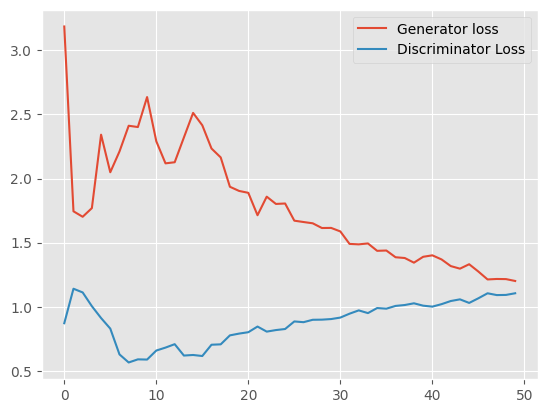

In [12]:
# 13-33 생성자와 판별자의 오차 확인

plt.figure()

plt.plot(losses_g, label='Generator loss')
plt.plot(losses_d, label='Discriminator Loss')

plt.legend()
plt.show()

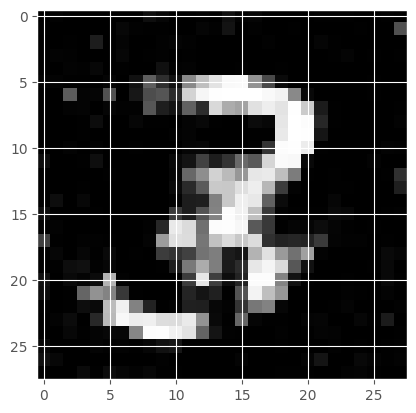

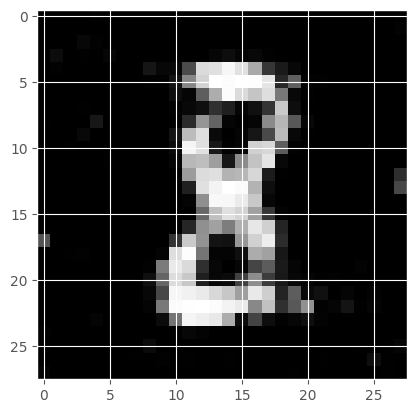

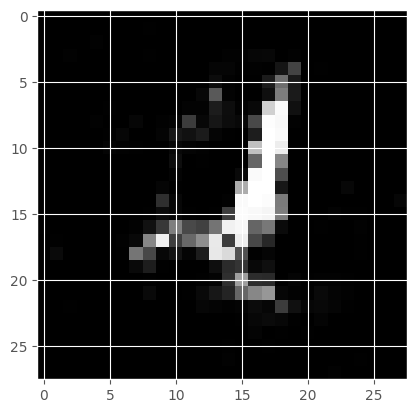

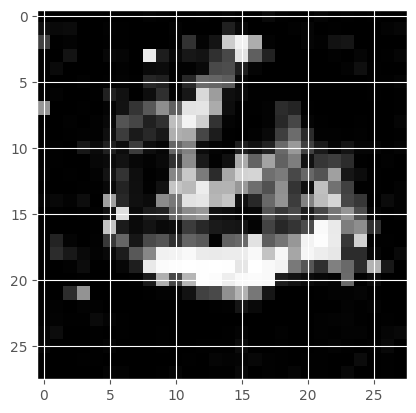

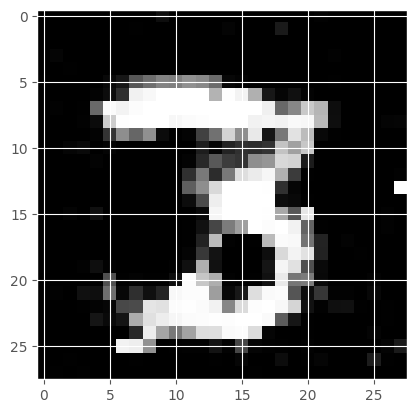

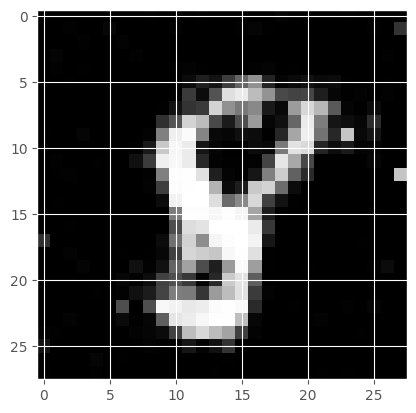

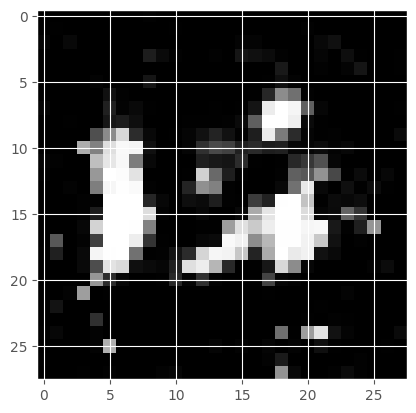

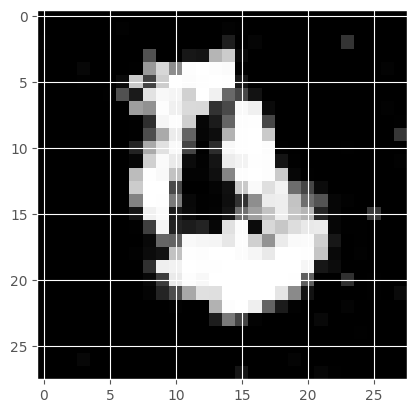

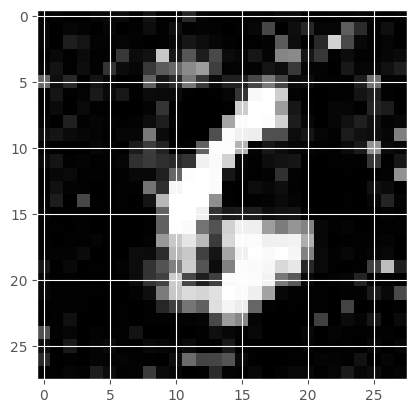

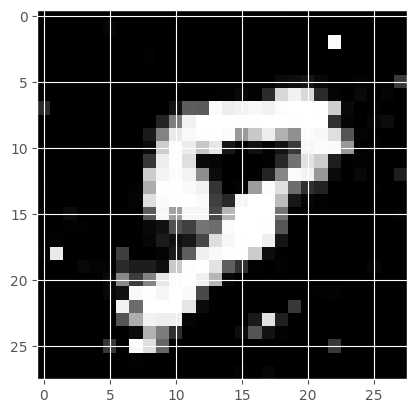

In [13]:
# 13-34 생성된 이미지 출력

import numpy as np  # 배열 변환을 위해 사용

fake_images = generator(torch.randn(b_size, nz).to(device))

for i in range(10):
    fake_images_img = np.reshape(
        fake_images.data.cpu().numpy()[i],
        (28, 28)
    )

    plt.imshow(fake_images_img, cmap='gray')
    plt.savefig('../chap13/img/fake_images_img' + str(i) + '.png')
    plt.show()

# 13.4 GAN 파생 기술

- DCGAN = GAN 학습에 CNN 사용하는 것
> GAN과 DCGAN은 가짜 이미지 생성을 위해 임의의 노이즈 값을 사용
- cGAN은 시드 역할을 하는 임의의 노이즈와 함께 조건 추가
- CycleGAN은 사진이 주어졌을 때 다른 사진으로 변형시키는 모델

## 13.4.1 DCGAN

< 생성자 네트워크 >
- 임의의 입력을 받아들여 판별자에서 사용가능한 이미지 데이터 생성
- 임의의 입력으로 주어지는 노이즈 데이터는 '가로x세로'로 변경해야 함
- 형태가 변경된 입력은 합성곱층으로 넘겨진 후 이미지 형태의 출력을 위해 분수-스트라이드 합성곱을 사용하여 출력값을 키움
- 특징
  - 풀링층 모두 삭제, 분수-스트라이드 합성곱 사용
  - 배치 정규화 이용 : 층이 많아도 안정적으로 기울기 계산 가능, 단 배치 정규화를 모든 계층마다 추가할 경우 안정성 떨어지기에 최종에서는 사용 X
  - 활성화 함수는 ReLU 이용, 최종에서는 hanh 사용

<판별자 네트워크 >
- 활성화 함수로 LeakyReLU 함수 사용, 최종에서는 시그모이드 사용
- 특징
  - 풀링층 모두 삭제, 스트라이드 합성곱 사용
  - 배치 정규화 이용 : 최초 입력층에서는 사용 X
  - 활성화 함수로 LeakyReLU 함수 사용, 최종에서는 시그모이드 사용

< 스트라이드 >
- 필터를 1칸 이상씩 이동시키며 합성곱 수행
- 출력 특성 맵 크기를 줄임
- 판별자에서 이미지 특징 추출 및 압축에 사용
- stride를 크게 주면 필터가 촘촘히 훑지 않고 건너뛰며 계산하므로 출력 크기가 줄어듦

< 분수-스트라이드 >
- 출력 크기를 키우기 위해 사용하는 합성곱 방식
- 특성 맵 사이사이에 빈 공간을 넣고 합성곱을 수행하여 출력 크기를 키우는 방식

| 구분       | 생성자 네트워크         | 판별자 네트워크         |
| -------- | ---------------- | ---------------- |
| 역할       | 가짜 이미지 생성        | 진짜/가짜 판별         |
| 입력       | 노이즈 벡터           | 실제 이미지 또는 생성 이미지 |
| 목표       | 작은 입력에서 큰 이미지 생성 | 큰 이미지에서 핵심 특징 추출 |
| 필요한 연산   | 출력 크기 키우기        | 출력 크기 줄이기        |
| 사용하는 합성곱 | 분수-스트라이드 합성곱     | 스트라이드 합성곱        |
| 방향       | 업샘플링             | 다운샘플링            |


## 13.4.2 cGAN


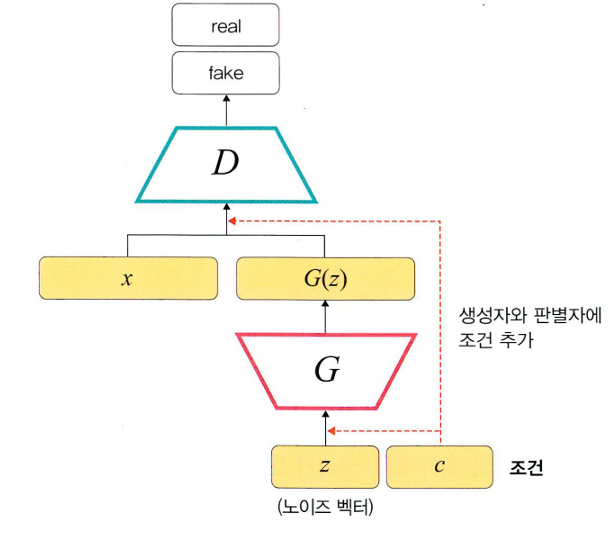

## 13.4.3 CycleGAN

- GAN과 DCGAN은 랜덤 노이즈를 입력으로 하므로 무작위 데이터가 생성되기 때문에 원하는 결과를 얻기 어려움

### PIX2PIX

- 임의의 노이즈 벡터가 아닌 이미지를 입력받아 다른 스타일의 이미지를 출력
- 지도 학습 알고리즘

< 생성자 네트워크 >
- 입력과 출력이 모두 이미지이기에 전체적으로 크기가 줄었다가 다시 커지는 인코더-디코더 구조
  -  크기가 줄어드는 인코더에서는 입력 데이터의 특정을 찾아냄
  - 크기가 다시 커지는 디코더에서는 이미지를 생성
  - 출력층의 활성화 함수는 하이퍼볼릭 탄젠트이기에 입력 또한 -1~1 사이의 값으로 변경해야 함

< 판별자 네트워크 >
- 스트라이드가 2인 합성곱층
- 다만 뒤쪽 두 계층은 stride가 1인 valid convolution 사용
  - valid convolution = 합성곱 과정에서 padding을 적용하지 않는 방식
  최종적으로 30 × 30 형태의 출력 데이터 생성

< PIX2PIX의 조건부 GAN 손실 함수 >
- 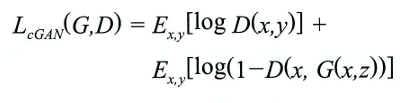

- 일반 GAN에서는 생성자가 판별자를 속이는 것이 주요 목표
- PIX2PIX에서는 단순히 판별자를 속이는 것만으로는 부족함
- 생성된 이미지가 실제 정답 이미지와 비슷해야 함
- 입력 이미지에 대응되는 정답 이미지 형태를 잘 따라야 함
- 따라서 PIX2PIX는 L1 손실 함수를 추가로 사용
> 최종 손실 함수
  - 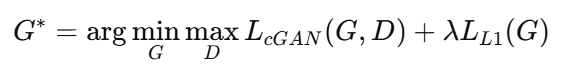

### CycleGAN

- PIX2PIX가 강력한 모댈이기는 하지만 데이터 쌍이 필요하다는 단점 존재
- 생성자 G는 이미지 X를 이미지 Y로 변환하며 생성자F는 이미지 Y를 다시 이미지 X로 변환